# Data Mining — Linear Regression — Mini-Project 1 (Energy Consumption)

**Course:** [CSEN911] Data Mining (Winter 2025)  
**Instructor:** Dr. Ayman Alserafi  
**Due:** 24 October 2025, 11:59 PM

**Dataset:** `energy_data.csv`  


> **Instructions:** For every step, write your own explanations and justifications and visualization in the provided Markdown prompts.




***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Valerie Antonious

ID: 59-30018

Tutorial: 2

---

Name: Hassan Ahmed

ID: 58-16514

Tutorial: 2

---


The dataset contains building-level energy readings and contextual attributes.

Each row represents a building observation. Columns include:

<div style="font-size:20px;">

| **Column** | **Description** |
|-------------|-----------------|
| **Building_ID** | Unique identifier for each building record. Used to distinguish one building entry from another. |
| **Building_Type** | Category describing the primary use of the building (e.g., Residential, Commercial, Industrial, Educational, etc.). |
| **Governorate** | The administrative region (governorate) where the building is located (e.g., Cairo, Giza, Alexandria). |
| **Neighborhood** | The smaller district or local area within the governorate where the building is located. |
| **Day_of_Week** | The day on which the energy consumption measurement was recorded (e.g., Sunday, Monday, etc.). |
| **Occupancy_Level** | The relative number of occupants or activity level in the building, typically categorized as *Low*, *Medium*, or *High*. |
| **Appliances_Usage_Level** | Indicates how intensively appliances are used in the building *Low*, *Medium*, or *High*. |
| **SquareFootage** | The total floor area of the building (numeric). Serves as a proxy for building size, often influencing energy usage. |
| **Last_Maintenance_Date** | The date of the last maintainance done on the building. |
| **Average_Temperature** | The average ambient temperature (in °C) recorded during the data period. |
| **Energy_Consumption** | The total energy used by the building, typically measured in kilowatt-hours (kWh).|

</div>


## Importing Libraries & Dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


## Data Inspection

Perform data inspection tasks here (recommended for data understanding).

In [25]:
df.info()  # Displays general information about the dataset such as the number of rows, columns, data types, and missing values in each column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           990 non-null    object 
 2   Governorate             873 non-null    object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   object 
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     990 non-null    float64
 10  Energy_Consumption      1100 non-null   object 
dtypes: float64(1), object(10)
memory usage: 94.7+ KB


Here we did this to see the information of the data. We found that all the columns are of type string except Average tempreture which is a float. We also found out the number of rows which are 1100 and the number of columns are 11. We also found the number of nulls in each column.

In [26]:
df.describe(include='all')  # Provides summary statistics for all columns, including both numerical and categorical data. Helps identify data ranges, missing values, and potential outliers.



,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
count,1100,990,873,1100,1100,1100,1100,1100,1100,990.000000,1100
unique,1100,3,3,848,42,3,3,1095,727,NaN,1100
top,BLD-2099-GL,Residential,Alexandria,Smouha,Sunday,High,Low,49653m2,2024-12-31,NaN,4722.59 kWh
freq,1,349,310,45,54,368,381,2,89,NaN,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.499404,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.703806,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.910000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.422500,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.260000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.970000,NaN


Here we saw that there are more than 7 unique values for the days of the week. We also found the mean, min, max and so on of the average tempreture and -4.9 is most likely an outlier because it is way past the 25% percentile.

In [27]:
# Displays all unique values in each selected categorical column to understand the different categories present in the dataset.
for col in ['Building_Type', 'Governorate', 'Day_of_Week',
            'Occupancy_Level', 'Appliances_Usage_Level']:
    print(f"{col}: {df[col].unique()}\n")


Building_Type: ['Residential' 'Commercial' 'Industrial' nan]

Governorate: ['Alexandria' 'Giza' 'Cairo' nan]

Day_of_Week: ['WeDnesday' 'tuesDAY' 'SunDay' 'TuesDay' 'Monday' 'saturDAY' 'MoNday'
 'FRIDAY' 'SUNDAY' 'friDAY' 'THURSDAY' 'Sunday' 'sunday' 'SuNday'
 'Saturday' 'THursday' 'MonDay' 'thursday' 'saturday' 'FriDay' 'WEDNESDAY'
 'SaturDay' 'Tuesday' 'Friday' 'FRIday' 'Thursday' 'MONDAY' 'SATURDAY'
 'SaTurday' 'wednesday' 'sunDAY' 'monDAY' 'monday' 'WednesDay' 'friday'
 'thursDAY' 'wednESDAY' 'Wednesday' 'ThursDay' 'TUESDAY' 'tuesday'
 'TuEsday']

Occupancy_Level: ['High' 'Medium' 'Low']

Appliances_Usage_Level: ['Low' 'High' 'Medium']



Here we saw the unique values in each column and we found that days of the week has multiple values that are equivilent.

## Data Pre-Processing & Cleaning

_Apply any data preprocessing and/or feature engineering below. Show/output the changes to the dataset._

In [28]:
# Fills missing values in categorical columns with the most frequent value (mode)
# and fills missing values in the numerical column with the mean.
df['Building_Type'] = df['Building_Type'].fillna(df['Building_Type'].mode()[0])
df['Governorate'] = df['Governorate'].fillna(df['Governorate'].mode()[0])
df['Average_Temperature'] = df['Average_Temperature'].fillna(df['Average_Temperature'].mean())



df

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.610000,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,33.499404,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.880000,4101.24 kWh
3,BLD-1003-HE,Residential,Alexandria,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.060000,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.820000,3279.17 kWh
...,...,...,...,...,...,...,...,...,...,...,...
1095,BLD-2095-OH,Commercial,Giza,(Dokki50,Saturday,High,Low,1161m2,2022-04-21,27.850000,3010.81 kWh
1096,BLD-2096-RH,Residential,Alexandria,Dokki-71,Sunday,Medium,Medium,37943m2,2024-10-31,36.230000,4248.49 kWh
1097,BLD-2097-JZ,Commercial,Giza,_Mohandessin91,SunDay,Low,Medium,1558,2021-04-18,20.000000,2843.6 kWh
1098,BLD-2098-ZP,Industrial,Alexandria,*23Smouha,saturday,Medium,Low,2145,2023-09-14,34.430000,3348.39 kWh


Here we replaced the nulls in the columns of the building type and governorate with the mode because they are catagorical. we replaced the nulls in the average tempreture with the mean because it is a numerical value.

In [29]:
# Capitalizes the first letter of each day name in the 'Day_of_Week' column for consistency in formatting
df['Day_of_Week'] = df['Day_of_Week'].str.capitalize()
df


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063m2,2020-01-01,28.610000,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,Tuesday,High,High,44372m2,2022-02-24,33.499404,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255,2021-02-22,37.880000,4101.24 kWh
3,BLD-1003-HE,Residential,Alexandria,+92Dokki,Tuesday,Low,High,13265,2023-07-30,35.060000,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.820000,3279.17 kWh
...,...,...,...,...,...,...,...,...,...,...,...
1095,BLD-2095-OH,Commercial,Giza,(Dokki50,Saturday,High,Low,1161m2,2022-04-21,27.850000,3010.81 kWh
1096,BLD-2096-RH,Residential,Alexandria,Dokki-71,Sunday,Medium,Medium,37943m2,2024-10-31,36.230000,4248.49 kWh
1097,BLD-2097-JZ,Commercial,Giza,_Mohandessin91,Sunday,Low,Medium,1558,2021-04-18,20.000000,2843.6 kWh
1098,BLD-2098-ZP,Industrial,Alexandria,*23Smouha,Saturday,Medium,Low,2145,2023-09-14,34.430000,3348.39 kWh


Here we fixed the capitalization issue in the column of the days of the week

In [30]:
# Extracts only the alphabetic characters and spaces from the 'Neighborhood' column and removes extra spaces for cleaner text data
df['Neighborhood'] = df['Neighborhood'].str.extract('([a-zA-Z\\s]+)', expand=False).str.strip()
df

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063m2,2020-01-01,28.610000,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372m2,2022-02-24,33.499404,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255,2021-02-22,37.880000,4101.24 kWh
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,Low,High,13265,2023-07-30,35.060000,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.820000,3279.17 kWh
...,...,...,...,...,...,...,...,...,...,...,...
1095,BLD-2095-OH,Commercial,Giza,Dokki,Saturday,High,Low,1161m2,2022-04-21,27.850000,3010.81 kWh
1096,BLD-2096-RH,Residential,Alexandria,Dokki,Sunday,Medium,Medium,37943m2,2024-10-31,36.230000,4248.49 kWh
1097,BLD-2097-JZ,Commercial,Giza,Mohandessin,Sunday,Low,Medium,1558,2021-04-18,20.000000,2843.6 kWh
1098,BLD-2098-ZP,Industrial,Alexandria,Smouha,Saturday,Medium,Low,2145,2023-09-14,34.430000,3348.39 kWh


Here we removed the extra characters in the neighborhood column

In [31]:
# Clean and convert the 'SquareFootage' and 'Energy_Consumption' columns:
# Remove the units ('m2' and 'kWh') from the string values, then convert them to numeric (float) for analysis.
df['SquareFootage'] = df['SquareFootage'].astype(str).str.replace('m2', '', regex=False).astype(float)
df['Energy_Consumption'] = df['Energy_Consumption'].astype(str).str.replace('kWh', '', regex=False).astype(float)
df


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.610000,2713.95
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,2022-02-24,33.499404,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.880000,4101.24
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.060000,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.820000,3279.17
...,...,...,...,...,...,...,...,...,...,...,...
1095,BLD-2095-OH,Commercial,Giza,Dokki,Saturday,High,Low,1161.0,2022-04-21,27.850000,3010.81
1096,BLD-2096-RH,Residential,Alexandria,Dokki,Sunday,Medium,Medium,37943.0,2024-10-31,36.230000,4248.49
1097,BLD-2097-JZ,Commercial,Giza,Mohandessin,Sunday,Low,Medium,1558.0,2021-04-18,20.000000,2843.60
1098,BLD-2098-ZP,Industrial,Alexandria,Smouha,Saturday,Medium,Low,2145.0,2023-09-14,34.430000,3348.39


Here we removed the kwh in the energy consumption to make the column float and we did the same by removing the m2 in the column of square footage

In [32]:
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'])
df['Days_Since_Last_Maintenance'] = (pd.Timestamp.today() - df['Last_Maintenance_Date']).dt.days
df['Day_type'] = df['Day_of_Week'].apply(lambda x: 'weekend' if x in ['Saturday', 'Friday'] else 'weekday')
df.head()



,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption,Days_Since_Last_Maintenance,Day_type
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.610000,2713.95,2123,weekday
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,2022-02-24,33.499404,5744.99,1338,weekday
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.880000,4101.24,1705,weekday
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.060000,3009.14,817,weekday
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.820000,3279.17,1169,weekday


Here we converted the Last_Maintenance_Date column from string format to datetime to enable date calculations. Then, we created a new column called Days_Since_Last_Maintenance to represent how long it has been since each building’s last maintenance, which can help capture maintenance effects on energy usage. Finally, we added a new feature Day_type that categorizes each day as either a weekday or weekend, which may influence energy consumption patterns.

## Exploratory Data Analysis

**Q1:** What are the most popular neighborhoods? plot all and order them on the graph (mention top 3)

**Visualization**

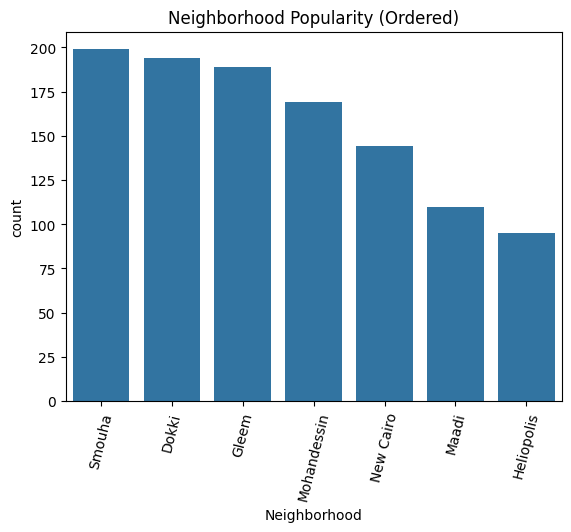

In [33]:
# Plot the frequency of each neighborhood, ordered by how often they appear in the dataset.
# This helps identify which neighborhoods are most common.
sns.countplot(x='Neighborhood', data=df, order=df['Neighborhood'].value_counts().index)
plt.title('Neighborhood Popularity (Ordered)')
plt.xticks(rotation=76)  # Rotate x-axis labels for better readability
plt.show()



**Answer for Q1:** the most popular neighborhoods are smouha, dokki, and gleem

**Q2:** Show the distribution of the energy consumption of each Building type.

Which type have the widest distribution of energy consumption?

Which (on average) has the highest consumption?.

**Visualization**

<Axes: xlabel='Building_Type', ylabel='Energy_Consumption'>

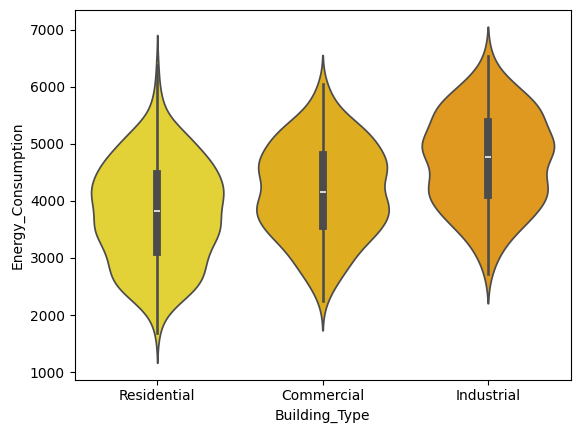

In [34]:
# Create a violin plot to show the distribution of energy consumption for each building type.
# The shape of each violin represents the spread and density of energy usage within that category.
sns.violinplot(x='Building_Type', y='Energy_Consumption', data=df, palette='Wistia', hue='Building_Type', legend=False)



**Answer for Q2: The building type that has the widest distribution of energy consumption is the residential. On average the one that has the highest consumption is the industrial.

**Q3:** How does the building size affect energy consumption?

**Visualization**

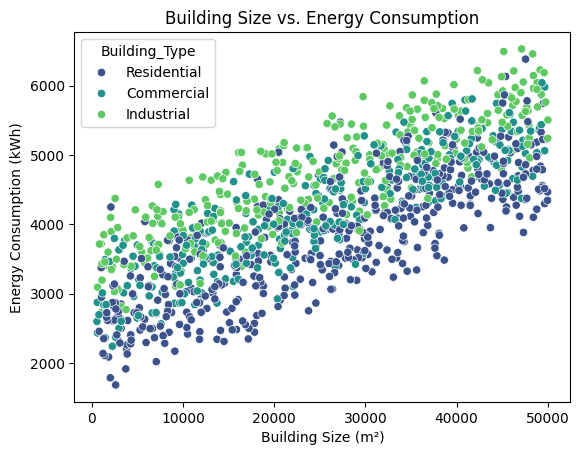

In [35]:
# Create a scatter plot to visualize the relationship between building size and energy consumption.
# Each point represents a building, colored by its type, to show how size impacts energy use across building categories.
sns.scatterplot(x='SquareFootage', y='Energy_Consumption', hue='Building_Type', data=df, palette='viridis')
plt.title('Building Size vs. Energy Consumption')
plt.xlabel('Building Size (m²)')
plt.ylabel('Energy Consumption (kWh)')
plt.show()


**Answer for Q3:** There is a positive correlation between the building size and energy consumption. The industrial buildings have the highest energy consumption. The Commercial buildings show the widest spread. Residential buildings have lower  energy consumption

**Q4:** Do buildings consume more energy if not maintained frequently?

**Visualization**

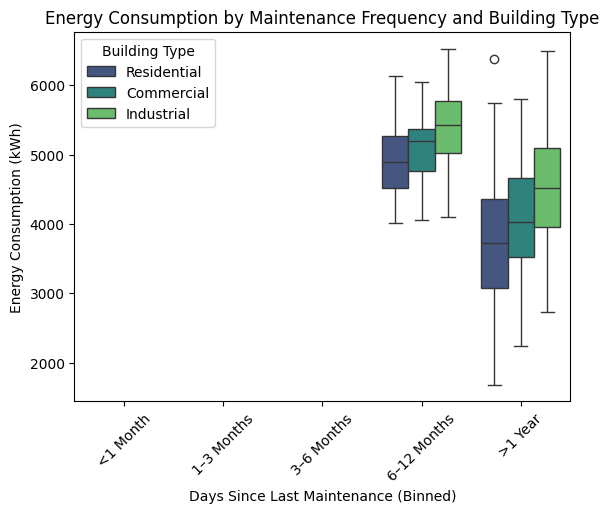

In [38]:
# Convert the 'Last_Maintenance_Date' column to datetime format
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'])

# Calculate the number of days since the last maintenance for each building
df['Days_Since_Maintenance'] = (pd.Timestamp.today() - df['Last_Maintenance_Date']).dt.days

# Group (bin) buildings based on how long ago maintenance was done
df['Maintenance_Bin'] = pd.cut(df['Days_Since_Maintenance'],
                               bins=[0, 30, 90, 180, 365, 10000],
                               labels=['<1 Month', '1–3 Months', '3–6 Months', '6–12 Months', '>1 Year'],
                               include_lowest=True)

# Create a box plot comparing energy consumption across maintenance bins by building type
sns.boxplot(data=df, x='Maintenance_Bin', y='Energy_Consumption', hue='Building_Type', palette='viridis')
plt.title('Energy Consumption by Maintenance Frequency and Building Type')
plt.xlabel('Days Since Last Maintenance (Binned)')
plt.ylabel('Energy Consumption (kWh)')
plt.xticks(rotation=45)
plt.legend(title='Building Type')
plt.show()




**Answer for Q4:** Buildings that go longer without maintenance usually show higher energy consumption industrial buildings show the highest energy usage across all maintenance intervals commercial buildings show the biggest spread in energy consumption also their usage increases noticeably with longer maintenance gaps residential buildings show lower and more consistent energy use but they also experience a little increase in consumption when maintenance is delayed.

**Q5:** Are all the numerical variables normally distributed, or is there any skewness?

**Visualization**

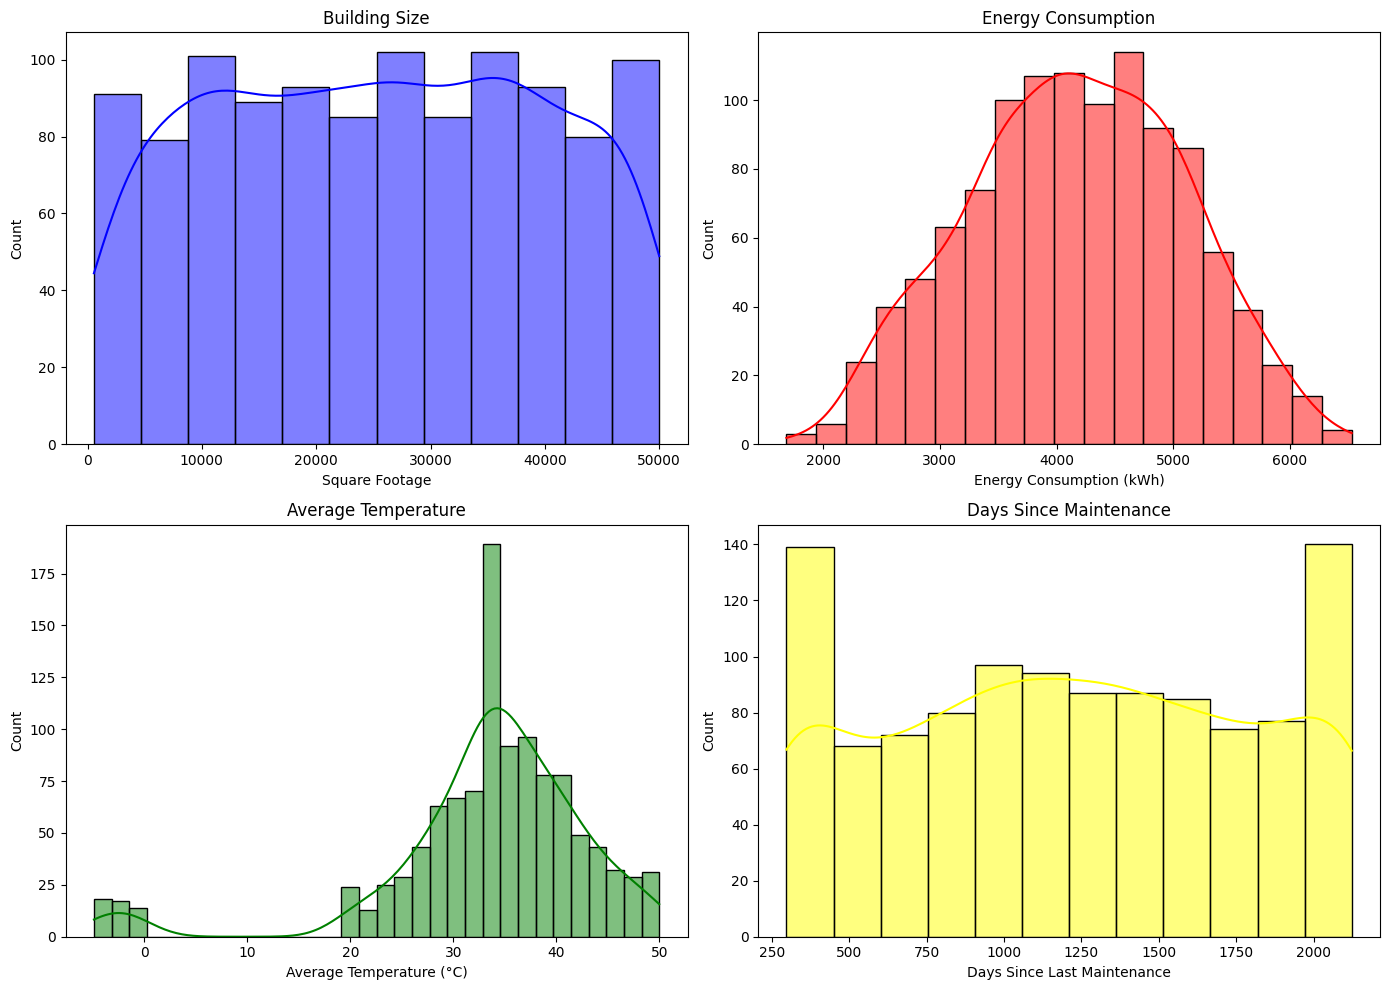

In [39]:
# Plot histograms (with KDE) for all key numerical variables to check their distributions.
# This helps identify skewness or normality in variables like building size, energy use, temperature, and maintenance timing.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['SquareFootage'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Building Size')
axes[0, 0].set_xlabel('Square Footage')

sns.histplot(df['Energy_Consumption'], kde=True, ax=axes[0, 1], color='red')
axes[0, 1].set_title('Energy Consumption')
axes[0, 1].set_xlabel('Energy Consumption (kWh)')

sns.histplot(df['Average_Temperature'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Average Temperature')
axes[1, 0].set_xlabel('Average Temperature (°C)')

sns.histplot(df['Days_Since_Maintenance'], kde=True, ax=axes[1, 1], color='yellow')
axes[1, 1].set_title('Days Since Maintenance')
axes[1, 1].set_xlabel('Days Since Last Maintenance')

plt.tight_layout()
plt.show()



**Answer for Q5:** we displayed the distributions of building size and energy consumption to check for the normality the building size is right skewed which means most buildings are small with a little amounts of very large ones also energy consumption also shows a right skewed distribution also the average temperature appears more evenly spread but does not follow a perfect curve lastly Days since last maintenance is also right skewed with most of the buildings having recent maintenance and a few with long delays.

**Q6:** What is multicollinearity? And why is it a problem for linear regression? Does this problem exist in this
dataset?

**Visualization**

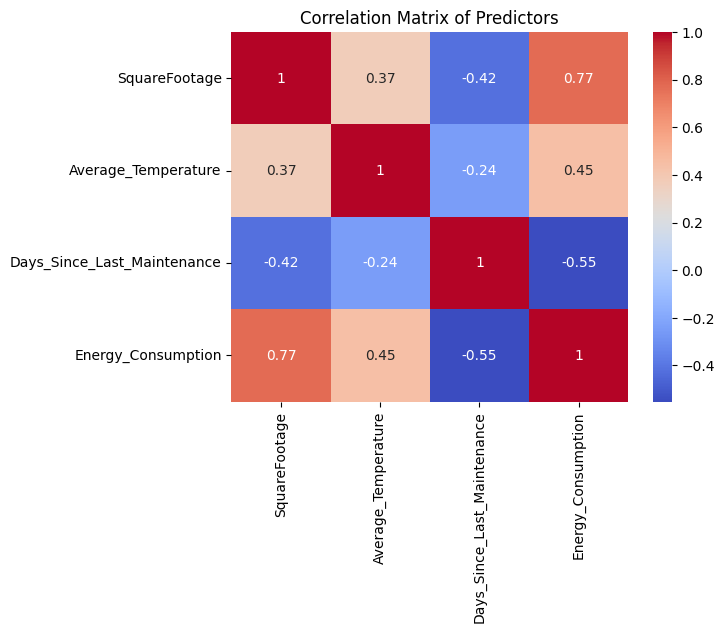

In [40]:
# Check for multicollinearity between numerical variables using a correlation heatmap
# Multicollinearity occurs when two or more predictors are highly correlated,
# which can distort the coefficients in linear regression models.

corr = df[['SquareFootage', 'Average_Temperature', 'Days_Since_Last_Maintenance', 'Energy_Consumption']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Predictors')
plt.show()



**Answer for Q6:** Multicollinearity is when two or more independent variables in are highly correlated with each other. This means they provide redundant information. This problem does occur in the data set. The correlation between SquareFootage and Energy_Consumption is 0.77, which is quite high.

## Data Preparation for Modelling

_Apply any additional data preparation steps needed before modelling below. Show/output the changes to the dataset._

In [41]:
# Keep only the relevant and cleaned columns for analysis
# This ensures the dataset contains all final engineered features and removes any unnecessary columns

df = df[['Building_Type', 'Governorate', 'Neighborhood',
         'Occupancy_Level', 'Appliances_Usage_Level', 'SquareFootage',
         'Average_Temperature', 'Days_Since_Last_Maintenance',
         'Day_type', 'Energy_Consumption']]

# Display the first few rows to confirm structure
df.head()


,Building_Type,Governorate,Neighborhood,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Average_Temperature,Days_Since_Last_Maintenance,Day_type,Energy_Consumption
0,Residential,Alexandria,Smouha,High,Low,7063.0,28.610000,2123,weekday,2713.95
1,Commercial,Giza,Mohandessin,High,High,44372.0,33.499404,1338,weekday,5744.99
2,Industrial,Cairo,New Cairo,Medium,Low,19255.0,37.880000,1705,weekday,4101.24
3,Residential,Alexandria,Dokki,Low,High,13265.0,35.060000,817,weekday,3009.14
4,Commercial,Alexandria,Smouha,Low,Low,13375.0,28.820000,1169,weekday,3279.17


we removed unnecessary columns like building id because each row has a uniques value so the model wont be able to extract patterns from it. and we removed day of week since we have day type and we also removed days since mainenance since we have days since last maintenance.

In [42]:
# Identify categorical columns that need to be converted into numerical format
categorical_cols = ['Building_Type', 'Governorate', 'Neighborhood',
                    'Occupancy_Level', 'Appliances_Usage_Level', 'Day_type']

# Apply one-hot encoding to categorical columns
# drop_first=True avoids multicollinearity by removing one dummy variable per category
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Ensure all encoded columns are of integer type (0 or 1)
df_encoded = df_encoded.astype(int)

# Display first few rows of the encoded dataset
df_encoded.head()




,SquareFootage,Average_Temperature,Days_Since_Last_Maintenance,Energy_Consumption,Building_Type_Industrial,Building_Type_Residential,Governorate_Cairo,Governorate_Giza,Neighborhood_Gleem,Neighborhood_Heliopolis,Neighborhood_Maadi,Neighborhood_Mohandessin,Neighborhood_New Cairo,Neighborhood_Smouha,Occupancy_Level_Low,Occupancy_Level_Medium,Appliances_Usage_Level_Low,Appliances_Usage_Level_Medium,Day_type_weekend
0,7063,28,2123,2713,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0
1,44372,33,1338,5744,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
2,19255,37,1705,4101,1,0,1,0,0,0,0,0,1,0,0,1,1,0,0
3,13265,35,817,3009,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
4,13375,28,1169,3279,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0


Here we did one hot encoding to all the catagorical values and transformed them to 0's and 1's.

In [43]:
# Separate features (X) and target variable (y)
X = df_encoded.drop('Energy_Consumption', axis=1)
y = df_encoded['Energy_Consumption']

# Import MinMaxScaler to normalize feature values between 0 and 1
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize the scaler and fit it on the feature data
scaler = MinMaxScaler()

# Apply scaling to all features
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back into a DataFrame with the same column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the scaled features
X_scaled.head()



,SquareFootage,Average_Temperature,Days_Since_Last_Maintenance,Building_Type_Industrial,Building_Type_Residential,Governorate_Cairo,Governorate_Giza,Neighborhood_Gleem,Neighborhood_Heliopolis,Neighborhood_Maadi,Neighborhood_Mohandessin,Neighborhood_New Cairo,Neighborhood_Smouha,Occupancy_Level_Low,Occupancy_Level_Medium,Appliances_Usage_Level_Low,Appliances_Usage_Level_Medium,Day_type_weekend
0,0.131541,0.592593,1.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.886219,0.685185,0.570099,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.378158,0.759259,0.771084,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.256994,0.722222,0.284775,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.259219,0.592593,0.477547,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


Here we normalized the numerical features to bring them to the same scale. and we kept energy consumption seperate because it is the dependent variable

In [44]:
from sklearn.model_selection import train_test_split

# Split the normalized data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Display the shape of each dataset to confirm correct splitting
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)



Training set: (880, 18)
Testing set: (220, 18)


we split the data to 80% training data and 20% testing.

## Modelling

_Apply the linear regression model below._

In [45]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model using the training data
lr_model.fit(X_train, y_train)

# Predict energy consumption for the test data
y_pred = lr_model.predict(X_test)



In this step, a Linear Regression model is trained to predict Energy Consumption based on the selected building and environmental features. The model learns the relationship between the input variables and the target variable using the training dataset.

## Model Evaluation

Evaluate the model you applied.

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the model on the test set
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print("Model Evaluation Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Model Evaluation Results:
Mean Absolute Error (MAE): 160.96
Mean Squared Error (MSE): 47612.30
R² Score: 0.94


After training the model, its performance is evaluated using the testing dataset. Evaluation metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score are used to measure the model’s accuracy and ability to generalize to unseen data.

## Conclusion and Recommendations

Comment on the model performance and your findings from model evaluation. State the problems (if any) and suggest possible solutions. Would you recommend this model for an electrcity company aiming to estimate the energy levels of each building?

**Answer**: The linear regression model achieved an R² score of 0.94, indicating that it can explain 94% of the variance in energy consumption. The MAE (160.96) and MSE (47,612.30) values are relatively low compared to the range of energy values, which suggests that the model’s predictions are highly accurate and consistent.

However, some minor errors remain, possibly due to non-linear relationships between features (e.g., temperature or occupancy levels) that a simple linear model cannot fully capture. Additionally, the dataset could benefit from more diverse samples or feature engineering (such as interaction terms or temporal patterns).

Overall, the model performs very well and can be recommended for an electricity company to estimate energy consumption per building, especially as a baseline predictive tool. For more precise forecasting, the company could later explore more advanced models like Random Forests or Gradient Boosting to capture complex patterns.

**BONUS**

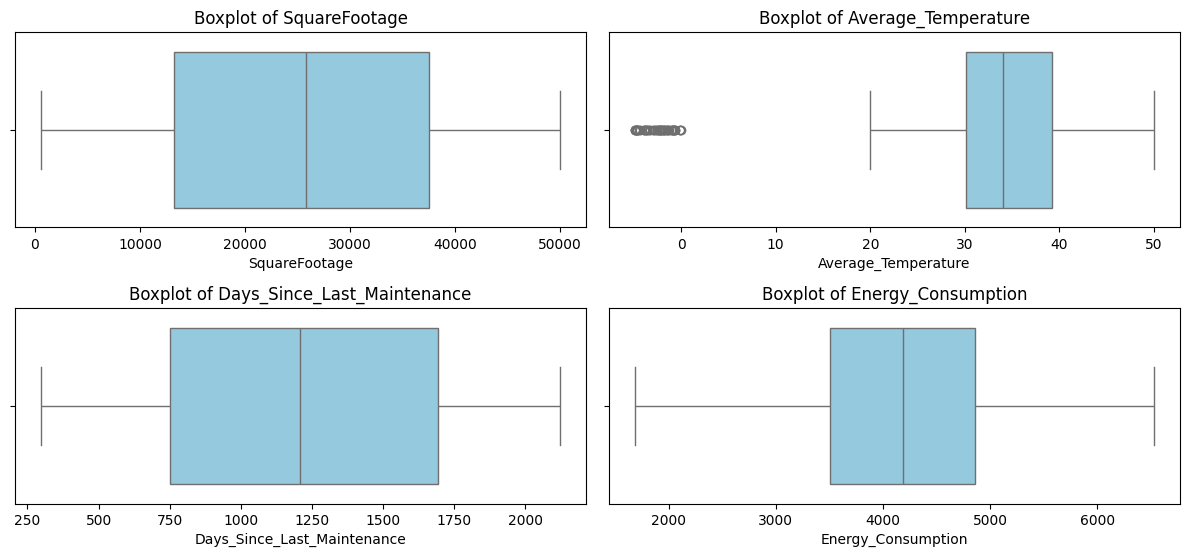

In [47]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))

# Loop through all numeric columns and create boxplots
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//2 + 1, 2, i)  # arrange plots in a grid
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


